# Etapa 1 · Análisis exploratorio, preprocesamiento y detección de *data leakage*

**Proyecto:** predicción de falla cardíaca (Heart Failure Prediction Dataset, Kaggle).
**Objetivo:** clasificación binaria, `HeartDisease` = 1 (enfermedad) o 0 (sano).

Este cuaderno cubre la Etapa 1 del proyecto:

1. Exploración del dataset y tratamiento de valores nulos.
2. Demostración de tres formas de **fuga de datos** (*data leakage*) y del flujo correcto.
3. Comparación de siete clasificadores con `Pipeline` + `GridSearchCV` (AUC y *accuracy*)
   y ranking final.

El código de entrenamiento y evaluación está encapsulado en funciones reutilizables del
módulo `src/modelado.py`.

In [1]:
import sys  # Acceso a la configuración del intérprete de Python
sys.path.insert(0, "..")  # Agrega la carpeta raíz del proyecto para poder importar el paquete src
import warnings  # Control de mensajes de advertencia
import numpy as np  # Cálculo numérico y generación de números aleatorios
import pandas as pd  # Manejo de tablas de datos
import matplotlib.pyplot as plt  # Creación de gráficos
import seaborn as sns  # Gráficos estadísticos de alto nivel
from sklearn.feature_selection import SelectKBest, f_classif  # Selección de variables por prueba F (para una de las demostraciones)
from sklearn.linear_model import LogisticRegression  # Regresión logística
from sklearn.metrics import roc_auc_score  # Área bajo la curva ROC
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split  # Búsqueda de hiperparámetros, validación cruzada y partición
from sklearn.pipeline import Pipeline  # Encadenamiento de transformaciones y modelo
from sklearn.preprocessing import MinMaxScaler  # Escalado de variables al rango [0, 1]
from sklearn.svm import SVC  # Máquina de vectores de soporte
from src import modelado as mod  # Funciones reutilizables del proyecto

warnings.filterwarnings("ignore", category=FutureWarning)  # Oculta avisos de versiones futuras de las librerías
sns.set_theme(style="whitegrid")  # Estilo visual de los gráficos
pd.set_option("display.width", 160)  # Ancho de impresión de las tablas

## 1. Carga y exploración del dataset

In [2]:
df = pd.read_csv(mod.RUTA_DATOS)  # Lee el archivo data/heart.csv
print(f"Dimensión: {df.shape[0]} pacientes × {df.shape[1]} columnas")  # Número de filas y columnas
df.head()  # Muestra las primeras cinco filas para verificar la lectura

Dimensión: 918 pacientes × 12 columnas


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()  # Tipo de dato y cantidad de valores no nulos de cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.describe().T  # Estadísticas descriptivas de las variables numéricas

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


| Variable | Significado |
|---|---|
| `Age` | Edad (años) |
| `Sex` | Sexo (M/F) |
| `ChestPainType` | Tipo de dolor torácico: TA (angina típica), ATA (atípica), NAP (no anginoso), ASY (asintomático) |
| `RestingBP` | Presión arterial en reposo (mm Hg) |
| `Cholesterol` | Colesterol sérico (mg/dl) |
| `FastingBS` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `RestingECG` | Electrocardiograma en reposo: Normal, ST, LVH |
| `MaxHR` | Frecuencia cardíaca máxima alcanzada |
| `ExerciseAngina` | Angina inducida por ejercicio (Y/N) |
| `Oldpeak` | Depresión del segmento ST inducida por ejercicio |
| `ST_Slope` | Pendiente del segmento ST: Up, Flat, Down |
| `HeartDisease` | **Objetivo**: 1 = enfermedad cardíaca |

                n     %
HeartDisease           
0             410  44.7
1             508  55.3


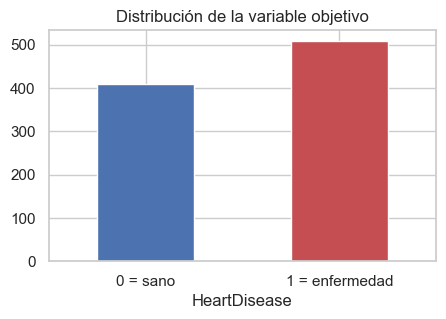

In [5]:
conteo = df[mod.OBJETIVO].value_counts().sort_index()  # Número de pacientes sanos (0) y enfermos (1)
print(pd.DataFrame({"n": conteo, "%": (100 * conteo / len(df)).round(1)}))  # Tabla con conteos y porcentajes
conteo.plot.bar(color=["#4C72B0", "#C44E52"], figsize=(5, 3), title="Distribución de la variable objetivo")  # Gráfico de barras de las clases
plt.xticks([0, 1], ["0 = sano", "1 = enfermedad"], rotation=0)  # Etiquetas legibles en el eje X
plt.show()  # Muestra el gráfico

Las clases están razonablemente balanceadas (55 % con enfermedad, 45 % sanos), por lo que
no hace falta remuestreo; aun así las particiones se harán **estratificadas**.

### Valores nulos y ceros imposibles

In [6]:
print("Nulos explícitos por columna:", int(df.isna().sum().sum()))  # El archivo no tiene celdas vacías
print("Filas duplicadas:", int(df.duplicated().sum()))  # Tampoco hay pacientes repetidos
ceros = (df[mod.COLUMNAS_CON_CEROS] == 0).sum()  # Cuenta los ceros en presión arterial y colesterol
print("\nCeros fisiológicamente imposibles:")  # Encabezado
print(ceros)  # Muestra el conteo por columna
sin_col = df["Cholesterol"] == 0  # Máscara de pacientes sin medición de colesterol
print(f"\nTasa de enfermedad con Cholesterol = 0: {df.loc[sin_col, mod.OBJETIVO].mean():.1%}")  # Enfermos entre quienes no tienen el dato
print(f"Tasa de enfermedad con Cholesterol > 0: {df.loc[~sin_col, mod.OBJETIVO].mean():.1%}")  # Enfermos entre quienes sí lo tienen

Nulos explícitos por columna: 0
Filas duplicadas: 0

Ceros fisiológicamente imposibles:
RestingBP        1
Cholesterol    172
dtype: int64

Tasa de enfermedad con Cholesterol = 0: 88.4%
Tasa de enfermedad con Cholesterol > 0: 47.7%


El archivo no tiene nulos explícitos, pero **172 pacientes (18,7 %) tienen `Cholesterol` = 0**
y uno tiene `RestingBP` = 0: valores imposibles que en realidad son datos no medidos.
Además, la ausencia del dato es informativa: el 88 % de los pacientes sin colesterol
registrado tiene enfermedad, frente al 48 % del resto (probablemente provienen de un hospital
o protocolo distinto).

**Decisión de preprocesamiento:** dentro del `Pipeline`, los ceros de esas dos columnas se
tratan como faltantes, se imputan con la **mediana aprendida solo en train** y se agrega una
columna indicadora de "dato faltante". Hacerlo dentro del `Pipeline` evita la fuga de datos.

### Variables numéricas y categóricas frente al objetivo

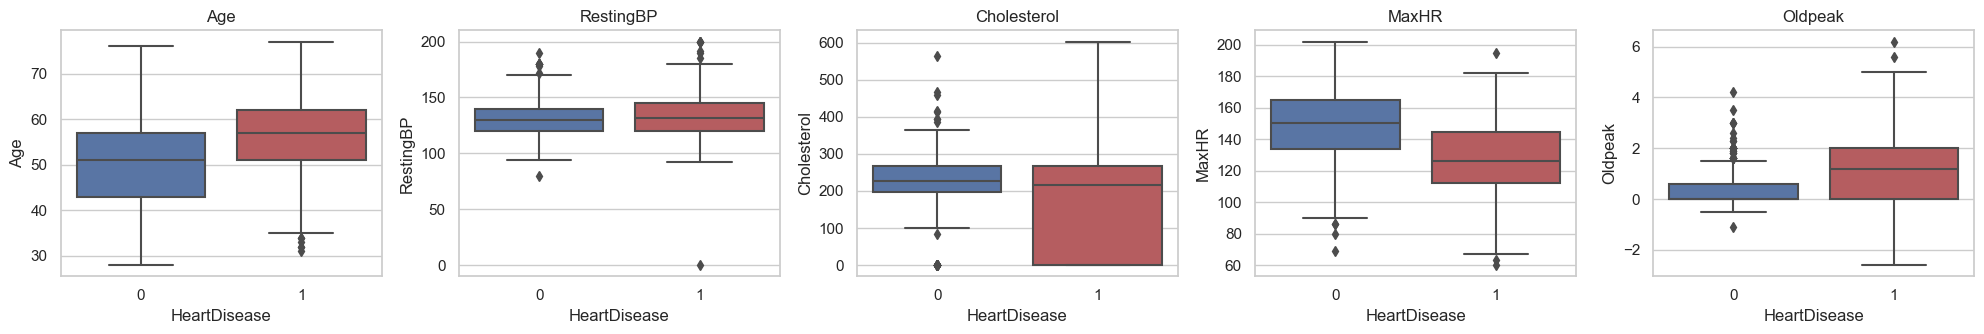

In [7]:
numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]  # Variables numéricas continuas
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))  # Una fila con cinco gráficos
for ax, col in zip(axes, numericas):  # Recorre cada variable numérica
    sns.boxplot(data=df, x=mod.OBJETIVO, y=col, ax=ax, palette=["#4C72B0", "#C44E52"])  # Diagrama de caja por clase
    ax.set_title(col)  # Título con el nombre de la variable
fig.tight_layout()  # Ajusta los márgenes
plt.show()  # Muestra la figura

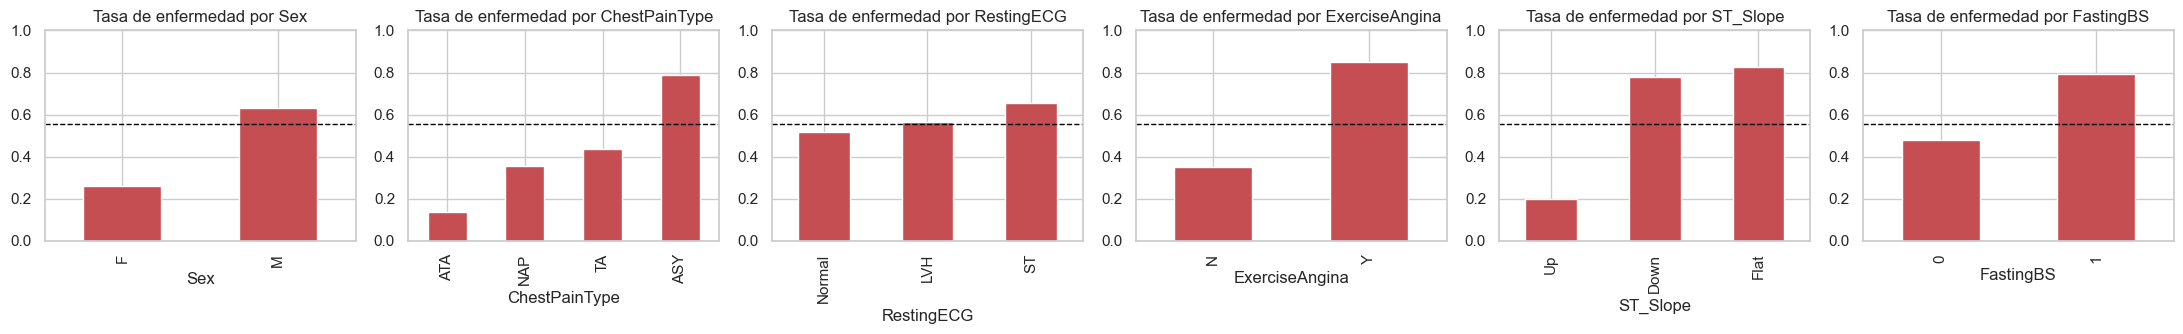

In [8]:
fig, axes = plt.subplots(1, 6, figsize=(22, 3.5))  # Una fila con seis gráficos
for ax, col in zip(axes, mod.COLUMNAS_CATEGORICAS + ["FastingBS"]):  # Recorre las categóricas y la glucosa en ayunas
    tasa = df.groupby(col)[mod.OBJETIVO].mean().sort_values()  # Proporción de enfermos en cada categoría
    tasa.plot.bar(ax=ax, color="#C44E52")  # Barras con la tasa de enfermedad
    ax.axhline(df[mod.OBJETIVO].mean(), color="black", ls="--", lw=1)  # Línea de la tasa global como referencia
    ax.set_title(f"Tasa de enfermedad por {col}")  # Título
    ax.set_ylim(0, 1)  # Misma escala en todos los gráficos
fig.tight_layout()  # Ajusta los márgenes
plt.show()  # Muestra la figura

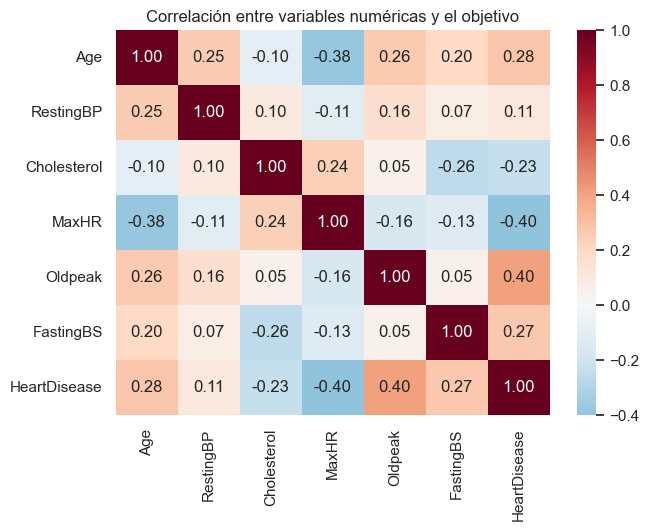

In [9]:
corr = df[numericas + ["FastingBS", mod.OBJETIVO]].corr()  # Matriz de correlación de Pearson
plt.figure(figsize=(7, 5))  # Tamaño de la figura
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)  # Mapa de calor con los coeficientes
plt.title("Correlación entre variables numéricas y el objetivo")  # Título
plt.show()  # Muestra la figura

**Hallazgos del análisis exploratorio.**

* Los pacientes con enfermedad son mayores, alcanzan menor frecuencia cardíaca máxima
  (`MaxHR`) y tienen mayor `Oldpeak`.
* Las categóricas discriminan con fuerza: pendiente ST plana o descendente (`ST_Slope`),
  dolor torácico asintomático (`ASY`) y angina inducida por ejercicio elevan la tasa de
  enfermedad por encima del 75–80 %.
* No hay correlaciones altas entre predictoras numéricas (|r| < 0,4), así que no se
  elimina ninguna variable.
* La correlación negativa de `Cholesterol` con el objetivo es un artefacto de los ceros.

## 2. Demostración de *data leakage*

Hay fuga de datos cuando el modelo recibe, durante el entrenamiento o la validación,
información que no tendría en producción. Se muestran tres casos y el flujo correcto.

> **Nota sobre el ejemplo del enunciado.** El código de referencia agrega `leaky_feature`
> a `X` y la usa tanto en el flujo "con fuga" como en el flujo "sin fuga", por lo que ambos
> darían AUC ≈ 1. Aquí se separan los casos para que se vea qué produce cada tipo de fuga.

In [10]:
X, y = mod.cargar_datos()  # Carga las 11 variables predictoras y el objetivo
X_num = pd.get_dummies(X, drop_first=True).astype(float)  # Versión totalmente numérica (variables dummy) para los flujos "ingenuos"
resultados_fuga = {}  # Diccionario donde se guarda el AUC de cada escenario

### Caso A: fuga del objetivo (*target leakage*)

Se agrega una variable artificial construida a partir de la propia etiqueta. En la
práctica equivale a incluir información registrada **después** del diagnóstico (por ejemplo,
el tratamiento recetado).

In [11]:
rng = np.random.default_rng(0)  # Generador aleatorio reproducible
X_fuga = X_num.copy()  # Copia de las variables numéricas
X_fuga["leaky_feature"] = y + rng.normal(0, 0.01, size=len(y))  # Variable casi idéntica a la etiqueta (etiqueta + ruido mínimo)
escalador = MinMaxScaler()  # Escalador a [0, 1]
X_fuga_esc = escalador.fit_transform(X_fuga)  # ERROR deliberado: el escalador se ajusta con TODOS los datos antes de dividir
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_fuga_esc, y, test_size=0.2, random_state=42, stratify=y)  # Partición posterior al escalado
grid_l = GridSearchCV(SVC(probability=True), {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}, cv=5, scoring="roc_auc")  # Búsqueda de hiperparámetros del enunciado
grid_l.fit(X_tr_l, y_tr_l)  # Entrena con la variable que filtra la respuesta
resultados_fuga["A. Fuga del objetivo (leaky_feature)"] = roc_auc_score(y_te_l, grid_l.predict_proba(X_te_l)[:, 1])  # AUC en test (artificialmente perfecto)
print(f"AUC con leaky_feature: {resultados_fuga['A. Fuga del objetivo (leaky_feature)']:.3f}")  # Reporta el resultado

AUC con leaky_feature: 1.000


El AUC es prácticamente 1: el modelo "adivina" porque una variable contiene la respuesta.
Un `Pipeline` **no protege** contra este tipo de fuga; solo se evita revisando que cada
variable esté disponible en el momento de predecir. Señal de alarma: un desempeño
demasiado bueno para ser cierto.

### Caso B: fuga por preprocesamiento antes de dividir

Se elimina la variable artificial, pero se mantiene el otro error del flujo anterior:
imputar y escalar con todos los datos antes de la partición. Así, la mediana, el mínimo y
el máximo usados para transformar train ya "vieron" el conjunto de prueba.

In [12]:
X_b = X_num.copy()  # Variables numéricas sin la variable artificial
for col in mod.COLUMNAS_CON_CEROS:  # Recorre presión arterial y colesterol
    X_b[col] = X_b[col].replace(0, np.nan)  # Convierte los ceros imposibles en faltantes
    X_b[col] = X_b[col].fillna(X_b[col].median())  # ERROR deliberado: mediana calculada con todos los datos (train + test)
X_b_esc = MinMaxScaler().fit_transform(X_b)  # ERROR deliberado: escalado ajustado con todos los datos
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_b_esc, y, test_size=0.2, random_state=42, stratify=y)  # Partición posterior
grid_b = GridSearchCV(SVC(probability=True), {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}, cv=5, scoring="roc_auc")  # Misma búsqueda
grid_b.fit(X_tr_b, y_tr_b)  # Entrenamiento
resultados_fuga["B. Preprocesamiento antes de dividir"] = roc_auc_score(y_te_b, grid_b.predict_proba(X_te_b)[:, 1])  # AUC en test
print(f"AUC con preprocesamiento antes de dividir: {resultados_fuga['B. Preprocesamiento antes de dividir']:.3f}")  # Reporta el resultado

AUC con preprocesamiento antes de dividir: 0.930


### Caso C: selección de variables antes de la validación cruzada

El efecto del caso B suele ser pequeño cuando la transformación es simple. Para ver cuánto
puede engañar una fuga de preprocesamiento se usa un ejemplo extremo: 5.000 variables de
**ruido puro** y etiquetas reales. Si se eligen las 20 "mejores" variables usando todos los
datos y luego se valida, el AUC parece alto aunque no existe ninguna señal.

In [13]:
ruido = rng.normal(size=(len(y), 5000))  # 5.000 variables aleatorias sin relación alguna con la enfermedad
seleccion_previa = SelectKBest(f_classif, k=20).fit_transform(ruido, y)  # ERROR deliberado: selección con todas las filas (incluye las de validación)
auc_mal = cross_val_score(LogisticRegression(max_iter=1000), seleccion_previa, y, cv=5, scoring="roc_auc").mean()  # Validación cruzada sobre variables ya "contaminadas"
flujo_ok = Pipeline([("seleccion", SelectKBest(f_classif, k=20)), ("clf", LogisticRegression(max_iter=1000))])  # Flujo correcto: la selección va dentro del Pipeline
auc_bien = cross_val_score(flujo_ok, ruido, y, cv=5, scoring="roc_auc").mean()  # La selección se repite en cada pliegue solo con su parte de entrenamiento
resultados_fuga["C. Ruido puro, selección ANTES de validar"] = auc_mal  # Guarda el AUC inflado
resultados_fuga["C. Ruido puro, selección DENTRO del Pipeline"] = auc_bien  # Guarda el AUC honesto
print(f"AUC (ruido) con selección previa: {auc_mal:.3f}   |   con Pipeline: {auc_bien:.3f}")  # Reporta ambos

AUC (ruido) con selección previa: 0.709   |   con Pipeline: 0.487


### Flujo correcto (sin fuga)

1. Se divide **primero** en train y test.
2. Todo el preprocesamiento (imputación, escalado, codificación) vive dentro de un
   `Pipeline`, de modo que `GridSearchCV` lo reajusta en cada pliegue solo con la parte de
   entrenamiento.
3. El conjunto de prueba se usa una única vez, al final.

In [14]:
X_train, X_test, y_train, y_test = mod.dividir_datos(X, y)  # Partición 80/20 estratificada ANTES de transformar
modelo_svc, malla_svc = mod.obtener_modelos()["SVC"]  # SVC y su malla de hiperparámetros (la del enunciado)
grid_svc = mod.train_pipeline(X_train, y_train, modelo_svc, malla_svc)  # Pipeline + GridSearchCV con validación cruzada de 5 pliegues
resultados_fuga["Flujo correcto (Pipeline, sin fuga)"] = roc_auc_score(y_test, grid_svc.predict_proba(X_test)[:, 1])  # AUC honesto en test
tabla_fuga = pd.Series(resultados_fuga, name="AUC").to_frame()  # Tabla con el AUC de cada escenario
tabla_fuga  # Muestra la tabla comparativa

,AUC
A. Fuga del objetivo (leaky_feature),1.000000
B. Preprocesamiento antes de dividir,0.929818
"C. Ruido puro, selección ANTES de validar",0.708895
"C. Ruido puro, selección DENTRO del Pipeline",0.486944
"Flujo correcto (Pipeline, sin fuga)",0.937351


**Lectura de la tabla.**

* **Caso A (AUC = 1,000):** la variable derivada de la etiqueta produce un modelo
  "perfecto" que sería inútil en producción, donde esa variable no existe.
* **Caso B (AUC = 0,930):** imputar y escalar antes de dividir no infló el resultado aquí; de
  hecho quedó ligeramente por debajo del flujo correcto (0,937), cuyo preprocesamiento es
  además más completo (indicador de dato faltante). Con transformaciones simples y 918 filas, la
  mediana y el rango cambian muy poco al incluir el test. Aun así el procedimiento es
  incorrecto: la estimación deja de ser honesta y el sesgo crece con muestras pequeñas o
  transformaciones más agresivas, como muestra el caso C.
* **Caso C (AUC = 0,709 frente a 0,487):** con variables de ruido puro, seleccionar antes de
  validar aparenta un AUC de 0,71 donde no hay ninguna señal; con la selección dentro del
  `Pipeline` el AUC vuelve a ≈ 0,5, el valor del azar.
* **Flujo correcto (AUC = 0,937):** es el desempeño que realmente puede esperarse del SVC.

**Regla práctica:** dividir primero, y que todo lo que "aprenda" de los datos (imputar,
escalar, codificar, seleccionar variables) viva dentro del `Pipeline`.

## 3. Comparación de modelos con `Pipeline` + `GridSearchCV`

Se entrenan siete clasificadores con el flujo sin fuga. Todos comparten el mismo
preprocesamiento (`construir_preprocesador`) y la misma función de entrenamiento:

```python
def train_pipeline(X_train, y_train, model, param_grid, cv=5, scoring="roc_auc"):
    pipe = Pipeline([("prep", construir_preprocesador()), ("clf", model)])
    pliegues = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEMILLA)
    grid = GridSearchCV(pipe, param_grid, cv=pliegues, scoring=scoring, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid
```

El ranking se ordena por el **AUC de validación cruzada** (calculado solo con train), no
por el AUC de test: elegir el modelo mirando el test sería otra forma de fuga.

In [15]:
ranking, busquedas = mod.comparar_modelos(X_train, y_train, X_test, y_test)  # Entrena y evalúa los siete modelos
ranking[["modelo", "auc_cv", "auc_test", "accuracy_test", "precision_test", "recall_test", "f1_test"]].round(4)  # Ranking comparativo

C:\DanielSR\Projects\proyecto_heart_disease\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\DanielSR\Projects\proyecto_heart_disease\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\user-pc\.conda\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\user-pc\.conda\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\user-pc\.conda\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht,

,modelo,auc_cv,auc_test,accuracy_test,precision_test,recall_test,f1_test
posicion,,,,,,,
1,RandomForest,0.9345,0.9304,0.8967,0.8807,0.9412,0.9100
2,GradientBoosting,0.9295,0.9306,0.9076,0.8972,0.9412,0.9187
3,LogisticRegression,0.9287,0.9304,0.8859,0.8785,0.9216,0.8995
4,SVC,0.9269,0.9374,0.8804,0.8704,0.9216,0.8952
5,KNN,0.9245,0.9402,0.9130,0.9057,0.9412,0.9231
6,NaiveBayes,0.9151,0.9099,0.8859,0.8857,0.9118,0.8986
7,DecisionTree,0.9087,0.8821,0.7772,0.7905,0.8137,0.8019


In [16]:
for _, fila in ranking.iterrows():  # Recorre el ranking
    print(f"{fila['modelo']:<20} {fila['mejores_parametros']}")  # Muestra los hiperparámetros ganadores de cada modelo

RandomForest         {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
GradientBoosting     {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 100}
LogisticRegression   {'clf__C': 1}
SVC                  {'clf__C': 1, 'clf__gamma': 0.1}
KNN                  {'clf__n_neighbors': 31, 'clf__weights': 'distance'}
NaiveBayes           {'clf__var_smoothing': 1e-09}
DecisionTree         {'clf__max_depth': 5, 'clf__min_samples_leaf': 20}


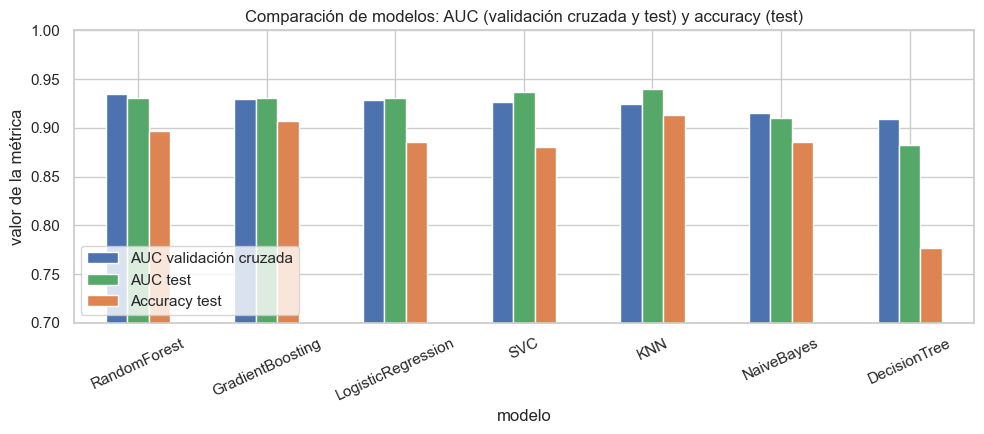

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))  # Figura para el gráfico comparativo
ranking.set_index("modelo")[["auc_cv", "auc_test", "accuracy_test"]].plot.bar(ax=ax, color=["#4C72B0", "#55A868", "#DD8452"])  # Barras agrupadas por modelo
ax.set_ylim(0.7, 1.0)  # Acerca la escala para apreciar las diferencias
ax.set_ylabel("valor de la métrica")  # Etiqueta del eje Y
ax.set_title("Comparación de modelos: AUC (validación cruzada y test) y accuracy (test)")  # Título
ax.legend(["AUC validación cruzada", "AUC test", "Accuracy test"], loc="lower left")  # Leyenda
plt.xticks(rotation=25)  # Inclina los nombres de los modelos
plt.tight_layout()  # Ajusta los márgenes
plt.show()  # Muestra el gráfico

**Lectura del ranking.**

| Posición | Modelo | AUC validación cruzada | AUC test | Accuracy test |
|---|---|---|---|---|
| 1 | RandomForest | 0,9345 | 0,9304 | 0,897 |
| 2 | GradientBoosting | 0,9295 | 0,9306 | 0,908 |
| 3 | LogisticRegression | 0,9287 | 0,9304 | 0,886 |
| 4 | SVC (modelo base) | 0,9269 | 0,9374 | 0,880 |
| 5 | KNN | 0,9245 | 0,9402 | 0,913 |
| 6 | NaiveBayes | 0,9151 | 0,9099 | 0,886 |
| 7 | DecisionTree | 0,9087 | 0,8821 | 0,777 |

* Los cinco primeros modelos están prácticamente empatados: sus AUC de validación cruzada
  difieren en 0,01, menos que la variación entre pliegues (desviación ≈ 0,03). Frente al
  SVC del enunciado, RandomForest, GradientBoosting y la regresión logística obtienen un AUC
  de validación algo mayor, pero la diferencia no es concluyente.
* En test el orden cambia (KNN y SVC quedan arriba), lo que confirma que con 184 pacientes
  de prueba las diferencias pequeñas son ruido. Por eso el modelo se elige con la validación
  cruzada y el test solo se usa para reportar.
* El árbol de decisión individual es claramente el peor (AUC test 0,882; accuracy 0,777): un
  solo árbol es inestable, y los ensambles corrigen justamente eso.
* Salvo el árbol individual, todos los modelos detectan más del 91 % de los enfermos (recall) con el umbral 0,5.

## 4. Conclusiones de la Etapa 1

1. El dataset no tiene nulos explícitos, pero sí **ceros imposibles** en `Cholesterol`
   (18,7 %) y `RestingBP`; se tratan como faltantes dentro del `Pipeline`, con indicador.
2. Una variable que filtra la etiqueta lleva el AUC a 1,0; el preprocesamiento antes de
   dividir puede fabricar desempeño inexistente (0,71 con ruido puro). El `Pipeline` evita
   la segunda fuga, no la primera.
3. Con el flujo correcto, el AUC real del problema ronda **0,93** para varios modelos.
   Se selecciona **RandomForest** por tener el mayor AUC de validación cruzada; el siguiente
   cuaderno lo evalúa en detalle y lo exporta para la API.